# 02 — Exploratory Data Analysis

Explore the kidney stone (N20) dataset without assumptions. Let patterns emerge from the data.

All plots are saved to `outputs/plots/` with a `02_` prefix.

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

from shared import OUTPUT_DIR, DATA_DIR, PLOT_DIR, METRICS_DIR

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

kidney = pd.read_parquet(DATA_DIR / "kidney_sih.parquet")
kidney["MORTE"] = pd.to_numeric(kidney["MORTE"], errors="coerce").fillna(0).astype(int)
kidney["DIAS_PERM"] = pd.to_numeric(kidney["DIAS_PERM"], errors="coerce").fillna(0)
kidney["VAL_TOT"] = pd.to_numeric(kidney["VAL_TOT"], errors="coerce").fillna(0)
print(f"Loaded {len(kidney):,} kidney stone admissions")

Loaded 206,500 kidney stone admissions


## 1. Data Quality & Schema

In [22]:
print("Shape:", kidney.shape)
print("\nColumn types:")
print(kidney.dtypes)
print("\nMissing values:")
missing = kidney.isnull().sum()
print(missing[missing > 0])
print("\nSample rows:")
kidney.head(3)

Shape: (206500, 23)

Column types:
DIAG_PRINC            object
DIAG_SECUN            object
PROC_REA              object
PROC_SOLIC            object
DIAS_PERM              int64
MUNIC_RES             object
MUNIC_MOV             object
CAR_INT               object
ESPEC                 object
CNES                  object
IDADE                  int64
COD_IDADE             object
SEXO                  object
VAL_TOT              float64
MORTE                  int64
DT_INTER      datetime64[ns]
DT_SAIDA              object
MARCA_UTI             object
COMPLEX               object
NATUREZA              object
UF_ZI                 object
year                   int32
month                  int32
dtype: object

Missing values:
Series([], dtype: int64)

Sample rows:


,DIAG_PRINC,DIAG_SECUN,PROC_REA,PROC_SOLIC,DIAS_PERM,MUNIC_RES,MUNIC_MOV,CAR_INT,ESPEC,CNES,...,VAL_TOT,MORTE,DT_INTER,DT_SAIDA,MARCA_UTI,COMPLEX,NATUREZA,UF_ZI,year,month
0,N201,0000,0305020021,0305020021,1,355030,355030,02,03,2066092,...,213.92,0,2016-01-03,20160104,00,02,00,350000,2016,1
1,N201,0000,0409010561,0409010561,1,352930,352930,02,01,2090961,...,766.11,0,2016-01-21,20160122,00,02,00,350000,2016,1
2,N201,0000,0409010561,0409010561,2,352610,353620,02,01,2077434,...,784.10,0,2016-01-26,20160128,00,02,00,350000,2016,1


In [23]:
print("Unique values per column:")
for col in kidney.columns:
    n = kidney[col].nunique()
    if n < 20:
        print(f"  {col}: {n} — {sorted(kidney[col].dropna().unique())}")
    else:
        print(f"  {col}: {n} unique values")

Unique values per column:
  DIAG_PRINC: 5 — ['N20', 'N200', 'N201', 'N202', 'N209']
  DIAG_SECUN: 1 — ['0000']
  PROC_REA: 193 unique values
  PROC_SOLIC: 262 unique values
  DIAS_PERM: 81 unique values
  MUNIC_RES: 908 unique values
  MUNIC_MOV: 307 unique values
  CAR_INT: 2 — ['01', '02']
  ESPEC: 7 — ['01', '02', '03', '07', '09', '13', '87']
  CNES: 510 unique values
  IDADE: 99 unique values
  COD_IDADE: 4 — ['2', '3', '4', '5']
  SEXO: 2 — ['1', '3']
  VAL_TOT: 28822 unique values
  MORTE: 2 — [np.int64(0), np.int64(1)]
  DT_INTER: 3744 unique values
  DT_SAIDA: 3733 unique values
  MARCA_UTI: 10 — ['00', '01', '51', '74', '75', '76', '78', '79', '85', '86']
  COMPLEX: 2 — ['02', '03']
  NATUREZA: 1 — ['00']
  UF_ZI: 268 unique values
  year: 11 — [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
  month: 12 — [np.int32(1), np.int32(2), np.int32(3), np.i

## 2. Volume Over Time

How many kidney stone admissions per year? Is there a trend?

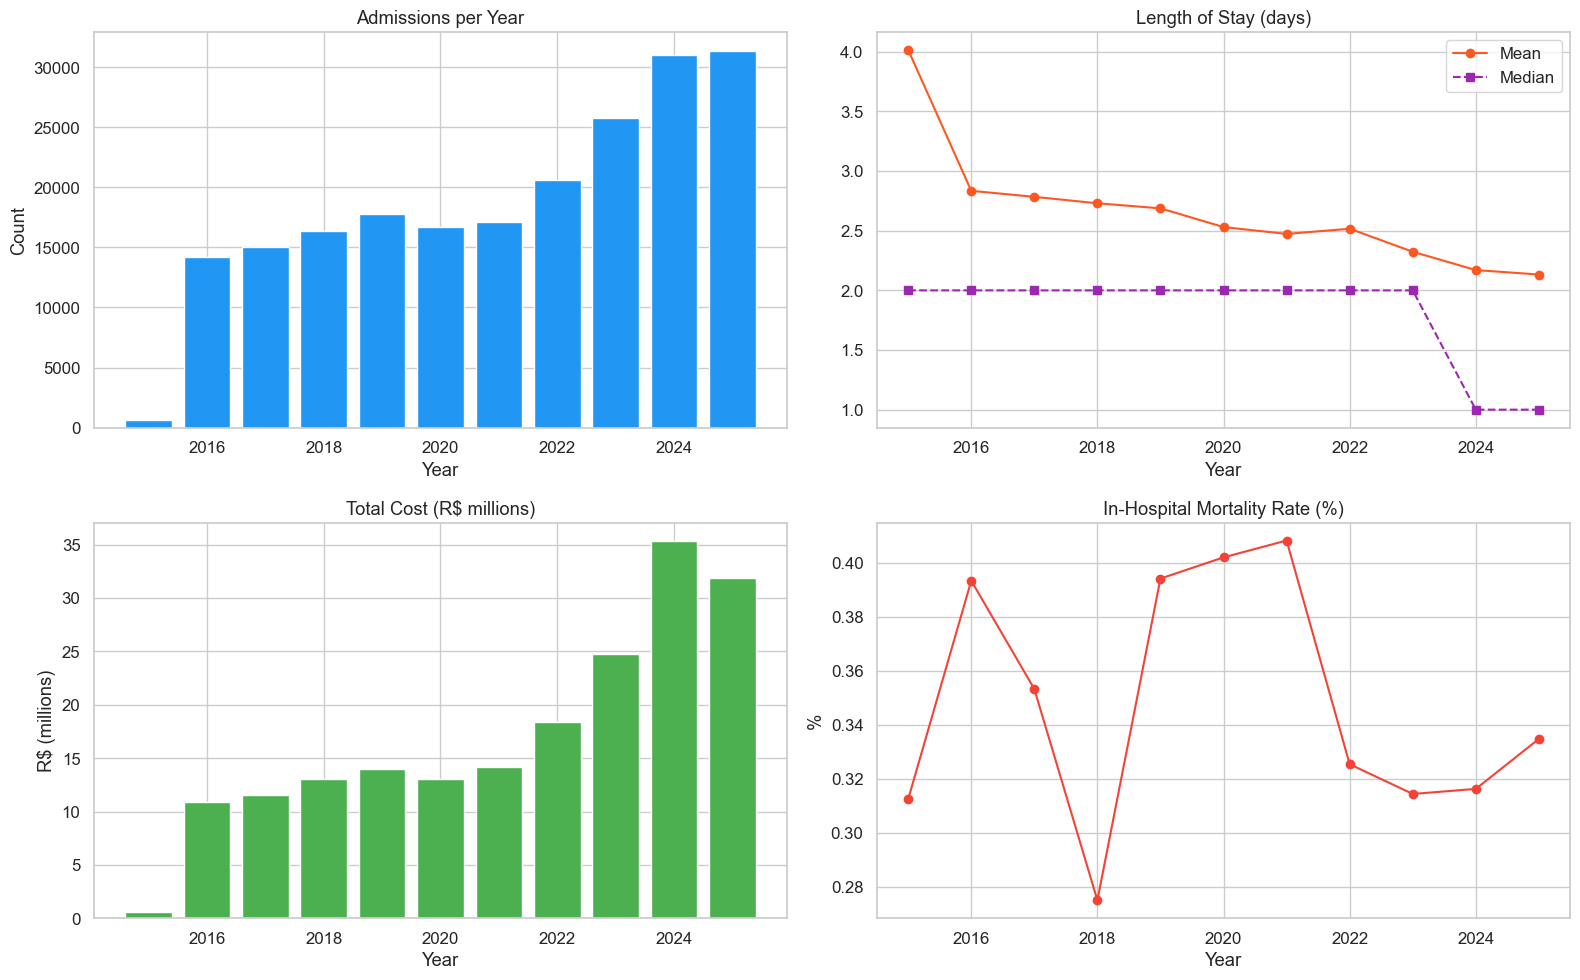

 year  admissions  avg_stay  median_stay    avg_cost  total_cost  mortality_rate
 2015         640  4.015625          2.0  932.635687   596886.84        0.003125
 2016       14234  2.834621          2.0  764.156767 10877007.42        0.003934
 2017       15002  2.784029          2.0  770.948136 11565763.93        0.003533
 2018       16362  2.730229          2.0  798.384905 13063173.81        0.002750
 2019       17757  2.687672          2.0  788.411481 13999822.67        0.003942
 2020       16664  2.530845          2.0  785.043648 13081967.35        0.004021
 2021       17144  2.472993          2.0  828.557025 14204781.63        0.004083
 2022       20588  2.516806          2.0  894.317535 18412209.41        0.003254
 2023       25762  2.323771          2.0  962.230849 24788991.12        0.003144
 2024       30985  2.170211          1.0 1139.660438 35312378.67        0.003163
 2025       31362  2.132772          1.0 1017.797739 31920172.70        0.003348


In [24]:
yearly = kidney.groupby("year").agg(
    admissions=("DIAG_PRINC", "count"),
    avg_stay=("DIAS_PERM", "mean"),
    median_stay=("DIAS_PERM", "median"),
    avg_cost=("VAL_TOT", "mean"),
    total_cost=("VAL_TOT", "sum"),
    mortality_rate=("MORTE", "mean"),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(yearly["year"], yearly["admissions"], color="#2196F3")
axes[0, 0].set_title("Admissions per Year")
axes[0, 0].set_ylabel("Count")

axes[0, 1].plot(yearly["year"], yearly["avg_stay"], "o-", color="#FF5722", label="Mean")
axes[0, 1].plot(yearly["year"], yearly["median_stay"], "s--", color="#9C27B0", label="Median")
axes[0, 1].set_title("Length of Stay (days)")
axes[0, 1].legend()

axes[1, 0].bar(yearly["year"], yearly["total_cost"] / 1e6, color="#4CAF50")
axes[1, 0].set_title("Total Cost (R$ millions)")
axes[1, 0].set_ylabel("R$ (millions)")

axes[1, 1].plot(yearly["year"], yearly["mortality_rate"] * 100, "o-", color="#F44336")
axes[1, 1].set_title("In-Hospital Mortality Rate (%)")
axes[1, 1].set_ylabel("%")

for ax in axes.flat:
    ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_yearly_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print(yearly.to_string(index=False))

## 3. Monthly Distribution

Is there any seasonal pattern?

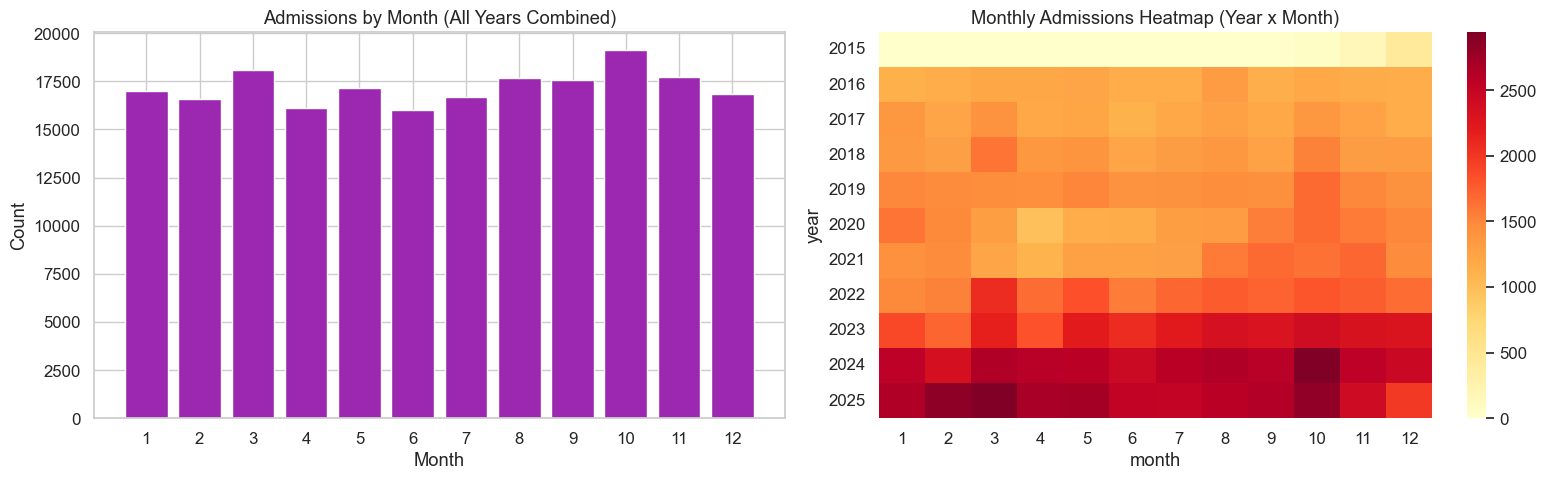

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall monthly distribution
monthly = kidney.groupby("month")["DIAG_PRINC"].count()
axes[0].bar(monthly.index, monthly.values, color="#9C27B0")
axes[0].set_title("Admissions by Month (All Years Combined)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(1, 13))

# Monthly heatmap by year
pivot = kidney.groupby(["year", "month"]).size().unstack(fill_value=0)
sns.heatmap(pivot, cmap="YlOrRd", annot=False, ax=axes[1])
axes[1].set_title("Monthly Admissions Heatmap (Year x Month)")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Demographics: Sex and Age

Who is being admitted?

In [26]:
# SEXO is stored as string: "1" = Male, "3" = Female
sex_map = {"1": "Male", "3": "Female"}
kidney["sex_label"] = kidney["SEXO"].astype(str).map(sex_map).fillna("Unknown")

print("Sex distribution:")
print(kidney["sex_label"].value_counts())
print(f"\nMale/Female ratio: {(kidney['sex_label'] == 'Male').sum() / (kidney['sex_label'] == 'Female').sum():.2f}")

Sex distribution:
sex_label
Female    109038
Male       97462
Name: count, dtype: int64

Male/Female ratio: 0.89


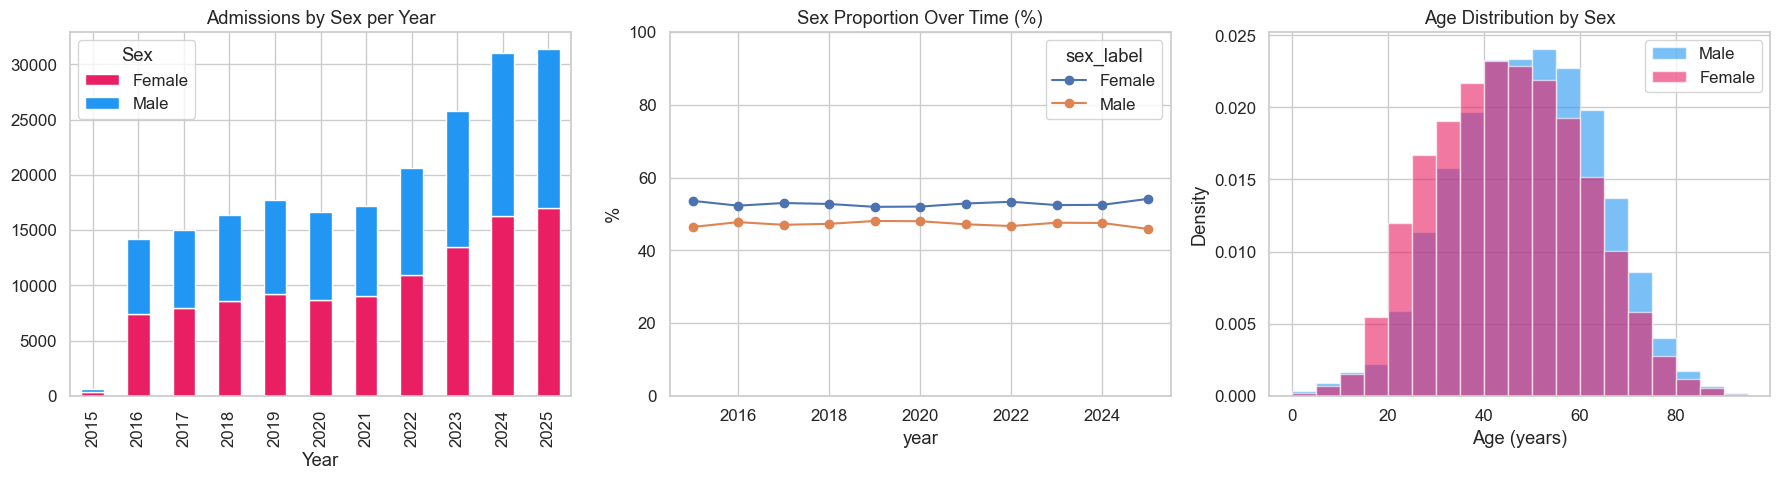

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sex distribution over time
sex_yearly = kidney.groupby(["year", "sex_label"]).size().unstack(fill_value=0)
sex_yearly.plot(kind="bar", stacked=True, ax=axes[0], color=["#E91E63", "#2196F3", "#9E9E9E"])
axes[0].set_title("Admissions by Sex per Year")
axes[0].set_xlabel("Year")
axes[0].legend(title="Sex")

# Sex ratio over time
sex_pct = sex_yearly.div(sex_yearly.sum(axis=1), axis=0) * 100
sex_pct.plot(kind="line", ax=axes[1], marker="o")
axes[1].set_title("Sex Proportion Over Time (%)")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 100)

# Age distribution by sex
# COD_IDADE="4" means age in years
age_in_years = kidney[kidney["COD_IDADE"].astype(str) == "4"].copy()
age_in_years["age"] = pd.to_numeric(age_in_years["IDADE"], errors="coerce")

for sex, color in [("Male", "#2196F3"), ("Female", "#E91E63")]:
    subset = age_in_years[age_in_years["sex_label"] == sex]["age"]
    axes[2].hist(subset, bins=range(0, 100, 5), alpha=0.6, label=sex, color=color, density=True)
axes[2].set_title("Age Distribution by Sex")
axes[2].set_xlabel("Age (years)")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Geography

Where are admissions concentrated? Are patients treated where they live?

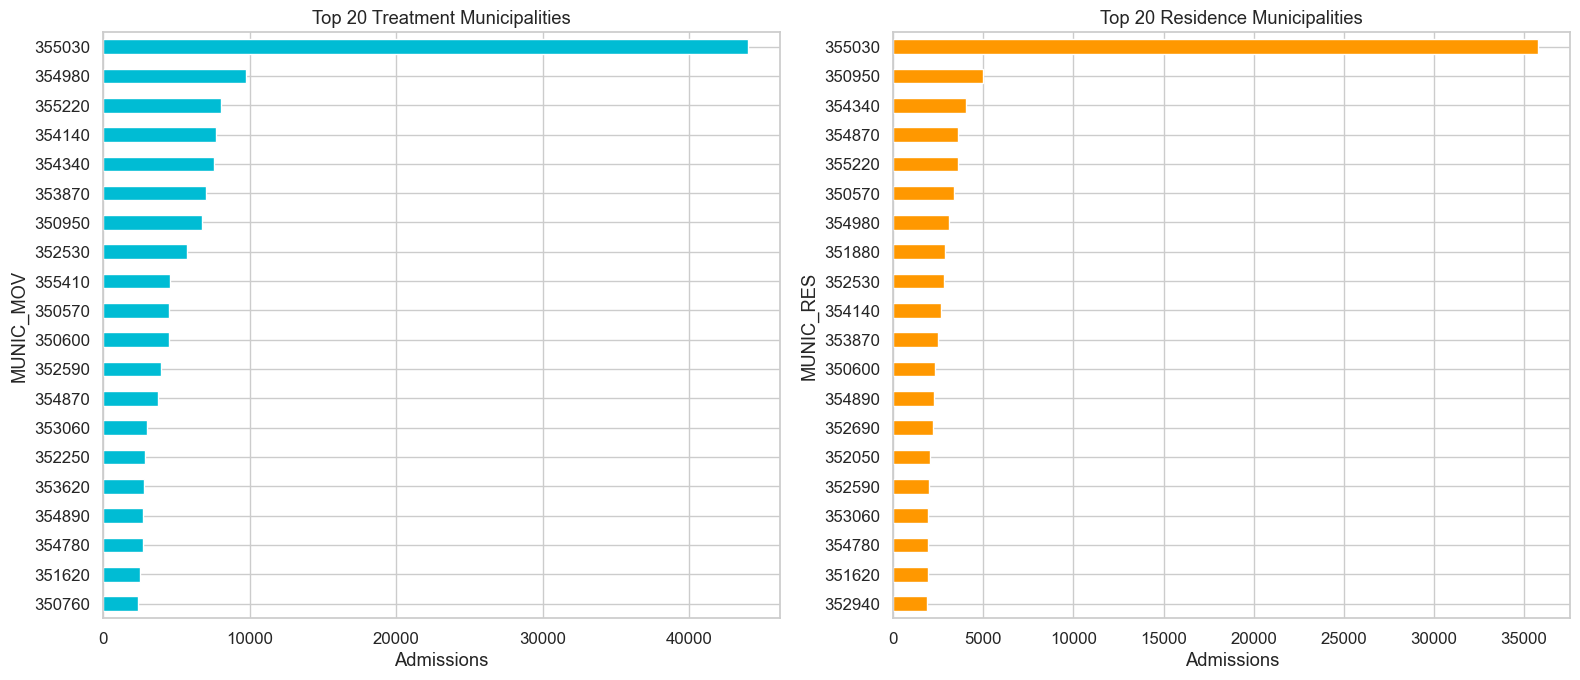

In [28]:
# Top treatment municipalities
top_treatment = kidney["MUNIC_MOV"].value_counts().head(20)
# Top residence municipalities
top_residence = kidney["MUNIC_RES"].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_treatment.plot(kind="barh", ax=axes[0], color="#00BCD4")
axes[0].set_title("Top 20 Treatment Municipalities")
axes[0].set_xlabel("Admissions")
axes[0].invert_yaxis()

top_residence.plot(kind="barh", ax=axes[1], color="#FF9800")
axes[1].set_title("Top 20 Residence Municipalities")
axes[1].set_xlabel("Admissions")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_geography.png", dpi=150, bbox_inches="tight")
plt.show()

Overall migration rate: 36.5% of patients treated outside their city


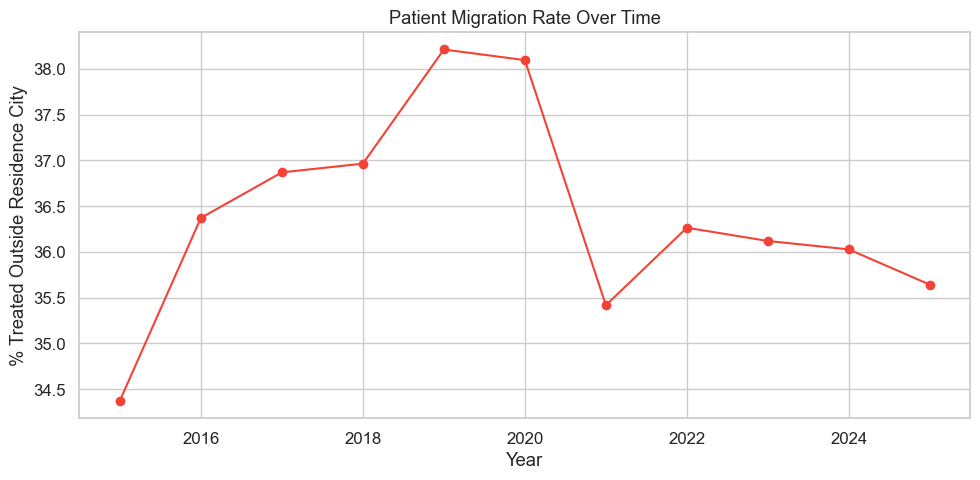

In [29]:
# Patient migration: do patients get treated where they live?
kidney["migrated"] = kidney["MUNIC_RES"].astype(str) != kidney["MUNIC_MOV"].astype(str)
migration_rate = kidney["migrated"].mean() * 100
print(f"Overall migration rate: {migration_rate:.1f}% of patients treated outside their city")

# Migration over time
migration_yearly = kidney.groupby("year")["migrated"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(migration_yearly.index, migration_yearly.values, "o-", color="#F44336")
ax.set_title("Patient Migration Rate Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("% Treated Outside Residence City")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_migration.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Sub-Diagnoses

What specific ICD-10 codes appear under N20?

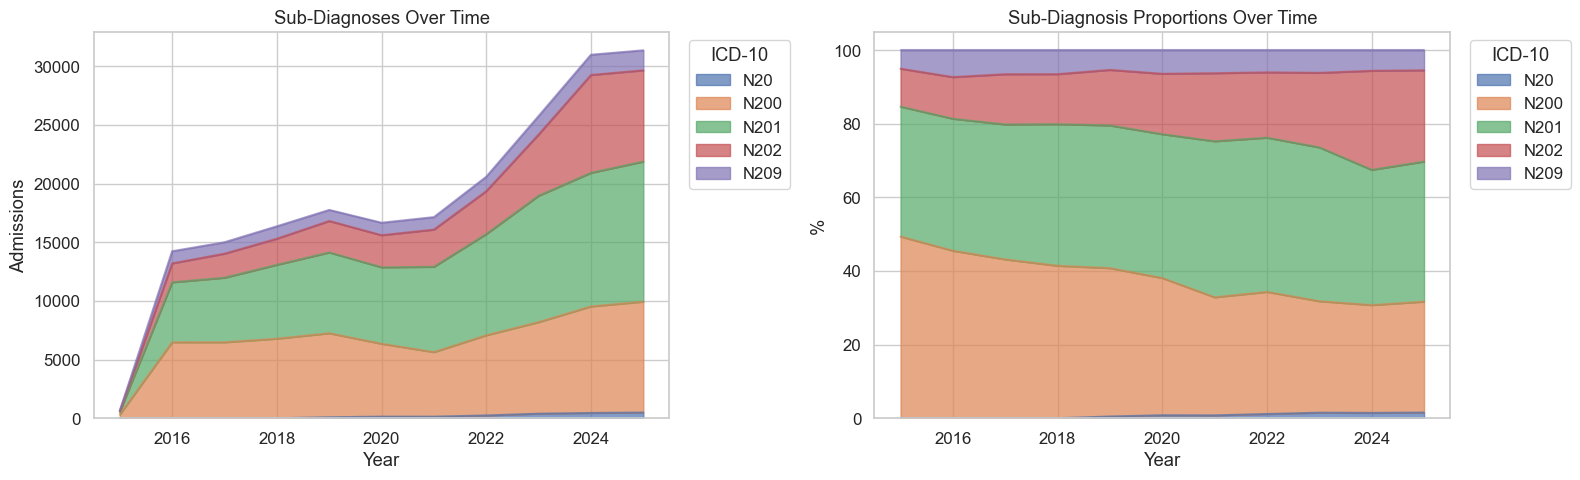

In [30]:
subdiag_yearly = kidney.groupby(["year", "DIAG_PRINC"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

subdiag_yearly.plot(kind="area", stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title("Sub-Diagnoses Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Admissions")
axes[0].legend(title="ICD-10", bbox_to_anchor=(1.02, 1))

# Proportion shift
subdiag_pct = subdiag_yearly.div(subdiag_yearly.sum(axis=1), axis=0) * 100
subdiag_pct.plot(kind="area", stacked=True, ax=axes[1], alpha=0.7)
axes[1].set_title("Sub-Diagnosis Proportions Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("%")
axes[1].legend(title="ICD-10", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_subdiagnosis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Procedures

What procedures are performed? Has the mix changed?

In [31]:
# Top procedure codes
proc_counts = kidney["PROC_REA"].astype(str).str.strip().value_counts()
print(f"Unique procedure codes: {len(proc_counts)}")
print("\nTop 15 procedures:")
print(proc_counts.head(15))

Unique procedure codes: 193

Top 15 procedures:
PROC_REA
0409010170    40973
0305020021    40657
0409010596    34036
0415010012    23275
0415020034    20597
0409010561    13145
0409010235     8040
0301060070     5851
0301060088     2967
0409010146     2784
0409010065     2450
0409010391     2380
0409010189     2138
0409010227     1759
0303150050      830
Name: count, dtype: int64


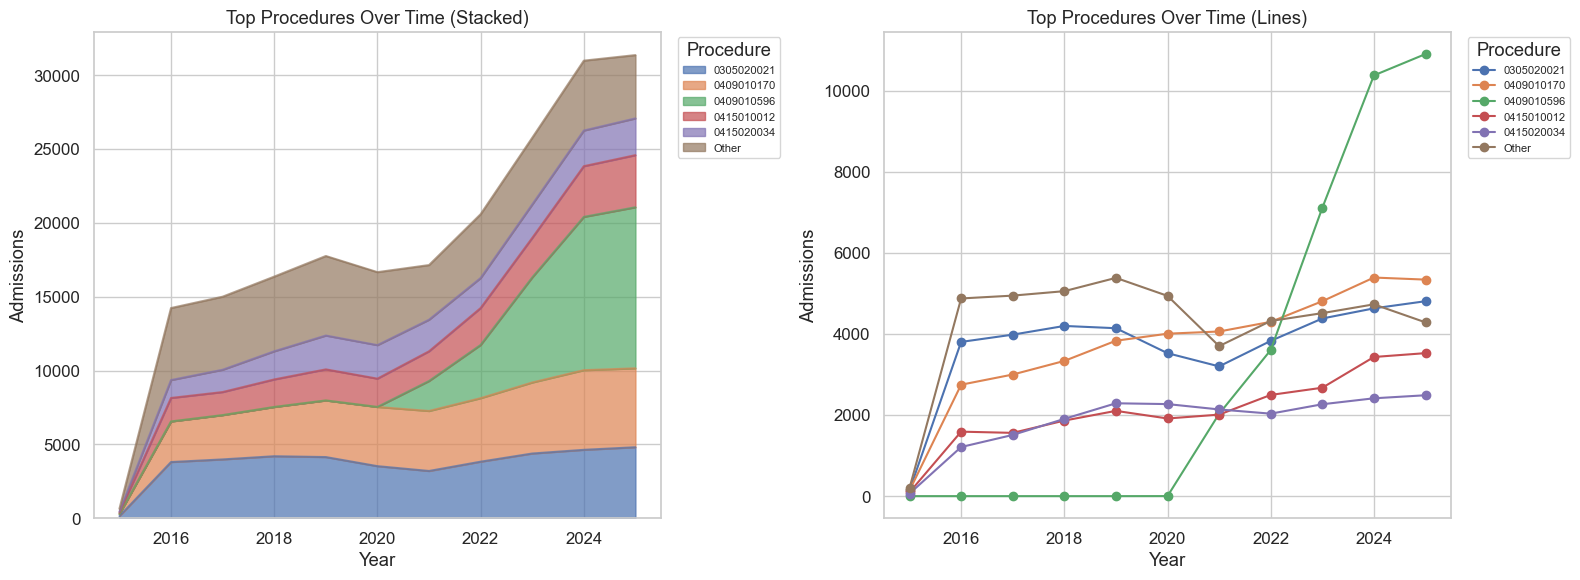

In [32]:
# Track top 5 procedures over time
top_procs = proc_counts.head(5).index.tolist()
kidney["proc_clean"] = kidney["PROC_REA"].astype(str).str.strip()
kidney["proc_top"] = kidney["proc_clean"].where(kidney["proc_clean"].isin(top_procs), "Other")

proc_yearly = kidney.groupby(["year", "proc_top"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

proc_yearly.plot(kind="area", stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title("Top Procedures Over Time (Stacked)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Admissions")
axes[0].legend(title="Procedure", fontsize=8, bbox_to_anchor=(1.02, 1))

proc_yearly.plot(kind="line", ax=axes[1], marker="o")
axes[1].set_title("Top Procedures Over Time (Lines)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Admissions")
axes[1].legend(title="Procedure", fontsize=8, bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_procedures.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Admission Type

Admission type distribution:
admission_type
Emergency    116672
Elective      89828
Name: count, dtype: int64


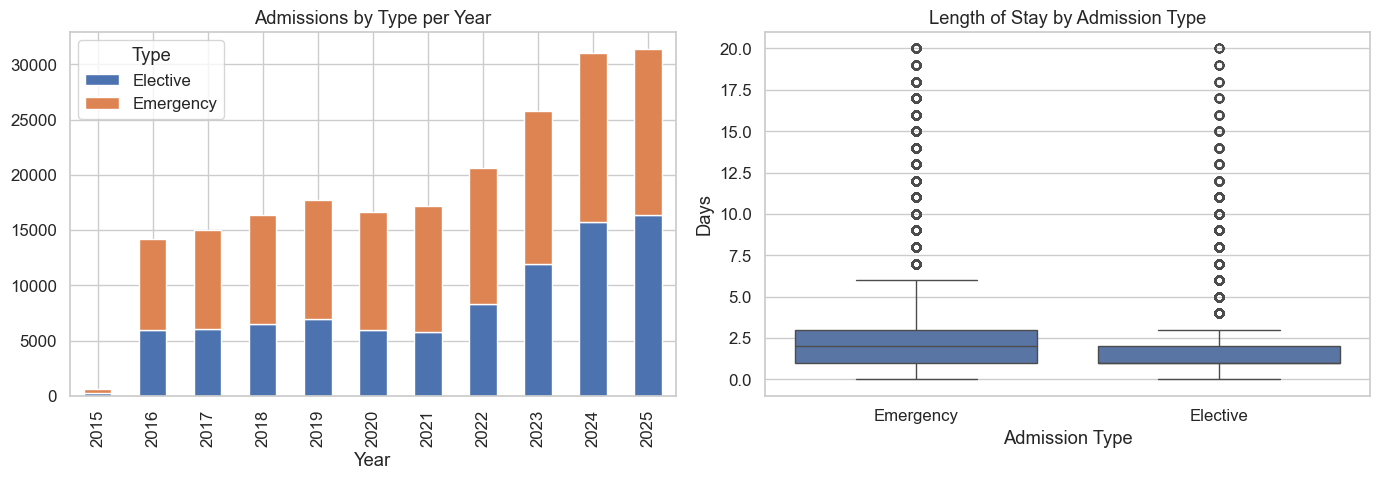

In [33]:
# CAR_INT is stored as string: "01" = Elective, "02" = Emergency
car_map = {"01": "Elective", "02": "Emergency", "05": "Other"}
kidney["admission_type"] = kidney["CAR_INT"].astype(str).map(car_map).fillna("Unknown")

print("Admission type distribution:")
print(kidney["admission_type"].value_counts())

adm_yearly = kidney.groupby(["year", "admission_type"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

adm_yearly.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Admissions by Type per Year")
axes[0].set_xlabel("Year")
axes[0].legend(title="Type")

# LOS by admission type
sns.boxplot(data=kidney[kidney["DIAS_PERM"] <= 20], x="admission_type", y="DIAS_PERM", ax=axes[1])
axes[1].set_title("Length of Stay by Admission Type")
axes[1].set_xlabel("Admission Type")
axes[1].set_ylabel("Days")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_admission_type.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Length of Stay Distribution

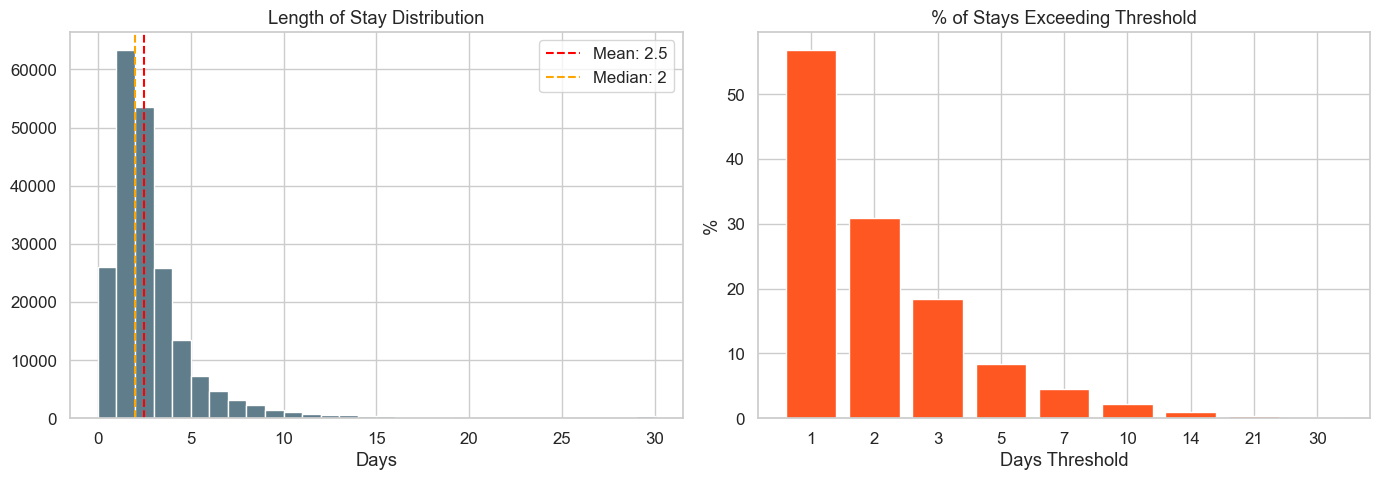

Stays > 7 days: 4.5%
Stays > 14 days: 1.0%
Stays > 30 days: 0.1%


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution (capped for visibility)
axes[0].hist(kidney["DIAS_PERM"].clip(upper=30), bins=30, color="#607D8B", edgecolor="white")
axes[0].axvline(kidney["DIAS_PERM"].mean(), color="red", linestyle="--", label=f"Mean: {kidney['DIAS_PERM'].mean():.1f}")
axes[0].axvline(kidney["DIAS_PERM"].median(), color="orange", linestyle="--", label=f"Median: {kidney['DIAS_PERM'].median():.0f}")
axes[0].set_title("Length of Stay Distribution")
axes[0].set_xlabel("Days")
axes[0].legend()

# Long stays
pct_gt7 = (kidney["DIAS_PERM"] > 7).mean() * 100
pct_gt14 = (kidney["DIAS_PERM"] > 14).mean() * 100
pct_gt30 = (kidney["DIAS_PERM"] > 30).mean() * 100

thresholds = [1, 2, 3, 5, 7, 10, 14, 21, 30]
pcts = [(kidney["DIAS_PERM"] > t).mean() * 100 for t in thresholds]
axes[1].bar([str(t) for t in thresholds], pcts, color="#FF5722")
axes[1].set_title("% of Stays Exceeding Threshold")
axes[1].set_xlabel("Days Threshold")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_stay_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Stays > 7 days: {pct_gt7:.1f}%")
print(f"Stays > 14 days: {pct_gt14:.1f}%")
print(f"Stays > 30 days: {pct_gt30:.1f}%")

## 10. Hospital-Level Variation

How much do hospitals differ in volume and outcomes?

Hospitals with >= 50 admissions: 251 (of 510 total)


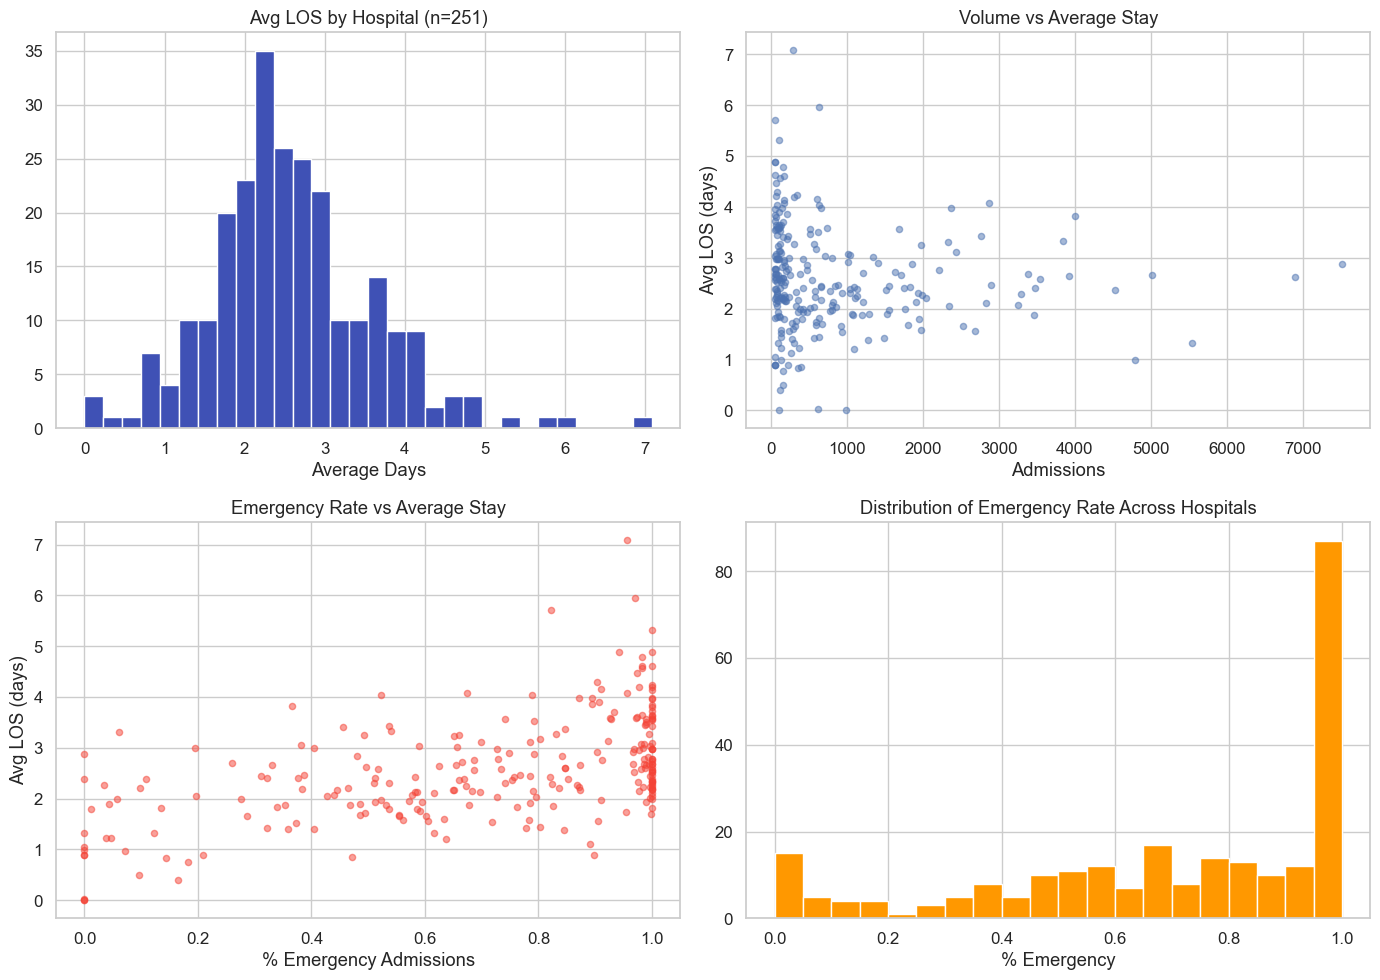

In [35]:
hospital = kidney.groupby("CNES").agg(
    volume=("DIAG_PRINC", "count"),
    avg_stay=("DIAS_PERM", "mean"),
    median_stay=("DIAS_PERM", "median"),
    mortality=("MORTE", "mean"),
    avg_cost=("VAL_TOT", "mean"),
    pct_emergency=("admission_type", lambda x: (x == "Emergency").mean()),
).reset_index()

# Only hospitals with meaningful volume
hospital_sig = hospital[hospital["volume"] >= 50]
print(f"Hospitals with >= 50 admissions: {len(hospital_sig)} (of {len(hospital)} total)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(hospital_sig["avg_stay"], bins=30, color="#3F51B5", edgecolor="white")
axes[0, 0].set_title(f"Avg LOS by Hospital (n={len(hospital_sig)})")
axes[0, 0].set_xlabel("Average Days")

axes[0, 1].scatter(hospital_sig["volume"], hospital_sig["avg_stay"], alpha=0.5, s=20)
axes[0, 1].set_title("Volume vs Average Stay")
axes[0, 1].set_xlabel("Admissions")
axes[0, 1].set_ylabel("Avg LOS (days)")

axes[1, 0].scatter(hospital_sig["pct_emergency"], hospital_sig["avg_stay"], alpha=0.5, s=20, c="#F44336")
axes[1, 0].set_title("Emergency Rate vs Average Stay")
axes[1, 0].set_xlabel("% Emergency Admissions")
axes[1, 0].set_ylabel("Avg LOS (days)")

axes[1, 1].hist(hospital_sig["pct_emergency"], bins=20, color="#FF9800", edgecolor="white")
axes[1, 1].set_title("Distribution of Emergency Rate Across Hospitals")
axes[1, 1].set_xlabel("% Emergency")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_hospital_variation.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Correlations

What numeric features correlate with length of stay?

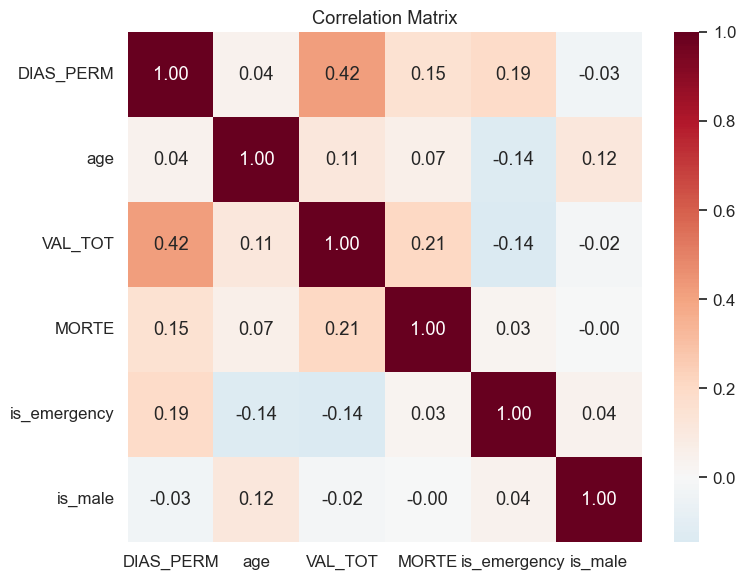

In [36]:
age_years = kidney[kidney["COD_IDADE"].astype(str) == "4"].copy()
age_years["age"] = pd.to_numeric(age_years["IDADE"], errors="coerce")
age_years["is_emergency"] = (age_years["CAR_INT"].astype(str) == "02").astype(int)
age_years["is_male"] = (age_years["SEXO"].astype(str) == "1").astype(int)

corr_cols = ["DIAS_PERM", "age", "VAL_TOT", "MORTE", "is_emergency", "is_male"]
corr_matrix = age_years[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Matrix")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Save EDA Observations

In [37]:
first_year = yearly.iloc[0]
last_year = yearly.iloc[-1]

eda_metrics = {
    "total_records": int(len(kidney)),
    "year_range": [int(kidney["year"].min()), int(kidney["year"].max())],
    "yearly_counts": yearly.set_index("year")["admissions"].to_dict(),
    "growth_pct": round((last_year["admissions"] / first_year["admissions"] - 1) * 100, 1),
    "sex_distribution": kidney["sex_label"].value_counts().to_dict(),
    "avg_stay": round(float(kidney["DIAS_PERM"].mean()), 2),
    "median_stay": float(kidney["DIAS_PERM"].median()),
    "pct_emergency": round(float((kidney["CAR_INT"].astype(str) == "02").mean() * 100), 1),
    "migration_rate_pct": round(float(migration_rate), 1),
    "mortality_rate_pct": round(float(kidney["MORTE"].mean() * 100), 3),
    "unique_hospitals": int(kidney["CNES"].nunique()),
    "unique_treatment_cities": int(kidney["MUNIC_MOV"].nunique()),
    "unique_procedures": int(proc_counts.shape[0]),
    "top_5_procedures": proc_counts.head(5).to_dict(),
    "top_5_treatment_cities": top_treatment.head(5).to_dict(),
    "pct_stay_gt7": round(pct_gt7, 1),
    "pct_stay_gt14": round(pct_gt14, 1),
}

with open(METRICS_DIR / "eda_metrics.json", "w") as f:
    json.dump(eda_metrics, f, indent=2, default=str)

print("EDA complete. Key observations:")
print(f"  Growth: {eda_metrics['growth_pct']}% over study period")
print(f"  Avg stay: {eda_metrics['avg_stay']} days (median: {eda_metrics['median_stay']})")
print(f"  Emergency rate: {eda_metrics['pct_emergency']}%")
print(f"  Migration rate: {eda_metrics['migration_rate_pct']}%")
print(f"  Mortality: {eda_metrics['mortality_rate_pct']}%")
print(f"  {eda_metrics['unique_hospitals']} hospitals across {eda_metrics['unique_treatment_cities']} cities")

EDA complete. Key observations:
  Growth: 4800.3% over study period
  Avg stay: 2.46 days (median: 2.0)
  Emergency rate: 56.5%
  Migration rate: 36.5%
  Mortality: 0.346%
  510 hospitals across 307 cities
